# Week 8 Lab: Frankenstein's Trading Strategy

**BUS 696: Generative AI in Finance**
**Professor Jonathan Hersh — Spring 2026**

---

## The Question

> Last week, one signal couldn't beat the market. What if we stitch together three?

Dr. Frankenstein had a simple thesis: one arm is useless, one brain is useless, one leg is useless — but bolt them all together and you've got something *alive*. We're doing the same thing, but with data instead of body parts.

**Our three body parts:**
1. **SEC EDGAR Insider Trading** — are executives putting their own money where their mouth is? *(the brain)*
2. **Wikipedia Pageviews** — is the crowd suddenly paying attention? *(the eyes)*
3. **FRED Yield Curve** — is the economy about to fall off a cliff? *(the survival instinct)*

## Why This Might Work (Or Might Create a Monster)

| Single Signal (Week 7) | Multi-Signal (Today) |
|---|---|
| One noisy feature | Three noisy features from *different* sources |
| "Is sentiment positive?" | "Are insiders buying while the crowd watches and the economy is healthy?" |
| Weak IC, dies with costs | Maybe a slightly less weak IC that still dies with costs |

## What You'll Do (~1 hour)

| Part | Topic | Time | What You Do |
|------|-------|------|-------------|
| 1 | Setup & Data | 10 min | Pull from 3 real APIs (no API keys needed) |
| 2 | Build & Standardize Signals | 10 min | Z-score each signal, lag it |
| 3 | Combine & Rank | 10 min | Equal-weight composite, cross-sectional ranking |
| 4 | Lagged Monthly Backtest | 10 min | Monthly rebalance, long/short |
| 5 | Transaction Costs & IC Gate | 10 min | The reality check |
| 6 | The Full Dashboard | 5 min | 4-panel professional output |
| 7 | Conclusion | 5 min | Did we create life, or just a corpse? |

## Core Deliverables
1. A composite signal from 3 real alt-data sources
2. Monthly cross-sectional backtest with costs — the 4-panel dashboard
3. **Written conclusion**: Is this strategy alive or dead? (3–5 sentences, be honest)

---

## Part 1: Setup & Data — Pulling Three Real Signals (~10 min)

We're pulling data from **three completely different sources**, none of which require an API key. This is real alt data, live from the internet.

Run these cells in order.

In [ ]:
# ============================================================
# SETUP: Libraries and color palette
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import requests
import time
from scipy.stats import spearmanr, zscore
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

NAVY = '#1E2761'
CORAL = '#F96167'
TEAL = '#028090'
GOLD = '#F9A825'
GRAY = '#6c757d'
GREEN = '#2E7D32'

np.random.seed(42)

def validate_df(df, name, min_rows=10):
    """Quick sanity check for any DataFrame we build."""
    assert isinstance(df, pd.DataFrame), f'{name} is not a DataFrame'
    assert len(df) >= min_rows, f'{name} has only {len(df)} rows (need >= {min_rows})'
    dup = df.duplicated().sum()
    if dup:
        print(f'  WARNING: {name} has {dup} duplicate rows')
    null_pct = df.isnull().mean()
    bad = null_pct[null_pct > 0.5]
    if len(bad):
        print(f'  WARNING: {name} columns >50% null: {bad.to_dict()}')
    print(f'  {name}: {len(df):,} rows x {len(df.columns)} cols  ✓')

print('Libraries loaded.')

Libraries loaded.


In [9]:
# ============================================================
# DATA PART 1: Stock prices from yfinance (the skeleton)
# ============================================================
tickers = ['AAPL', 'MSFT', 'TSLA', 'NVDA', 'AMZN', 'META', 'GOOGL',
           'JPM', 'BAC', 'XOM', 'DIS', 'NFLX', 'COIN', 'PFE', 'HD']

print(f'Downloading monthly prices for {len(tickers)} stocks...')
raw = yf.download(tickers, start='2018-01-01', end='2025-01-01')
prices = raw['Close']
monthly = prices.resample('ME').last()
monthly_ret = monthly.pct_change()

# Build panel
records = []
for t in monthly.index[1:]:
    for ticker in tickers:
        try:
            ret = monthly_ret.loc[t, ticker]
            if pd.isna(ret):
                continue
            records.append({'date': t, 'ticker': ticker, 'return': ret})
        except KeyError:
            continue

returns_panel = pd.DataFrame(records)
returns_panel = returns_panel.sort_values(['ticker', 'date']).reset_index(drop=True)

assert len(returns_panel) > 500, f'Price data too small ({len(returns_panel)} rows) — check yfinance'
validate_df(returns_panel, 'returns_panel', min_rows=500)
print(f'Date range: {returns_panel.date.min().strftime("%Y-%m")} to {returns_panel.date.max().strftime("%Y-%m")}')

[*********************100%***********************]  15 of 15 completed


  returns_panel: 1,206 rows x 3 cols  ✓
Date range: 2018-02 to 2024-12


In [10]:
# ============================================================
# DATA PART 2: SEC EDGAR insider trading (the brain)
# ============================================================
# Every time a corporate insider buys or sells stock, they must
# file a Form 4 with the SEC within 2 business days. We count
# how many filings each company gets per month.

# CIK numbers for our 15 stocks (these are like Social Security
# numbers, but for corporations)
cik_map = {
    'AAPL': '0000320193', 'MSFT': '0000789019', 'TSLA': '0001318605',
    'NVDA': '0001045810', 'AMZN': '0001018724', 'META': '0001326801',
    'GOOGL': '0001652044', 'JPM': '0000019617', 'BAC': '0000070858',
    'XOM': '0000034088', 'DIS': '0001744489', 'NFLX': '0001065280',
    'COIN': '0001679788', 'PFE': '0000078003', 'HD': '0000354950',
}

headers = {'User-Agent': 'BUS696 Course hersh@chapman.edu'}
insider_records = []

print('Pulling insider filings from SEC EDGAR...')
for ticker, cik in cik_map.items():
    try:
        url = f'https://data.sec.gov/submissions/CIK{cik}.json'
        r = requests.get(url, headers=headers, timeout=15)
        r.raise_for_status()
        filings = r.json()['filings']['recent']
        for date, form in zip(filings['filingDate'], filings['form']):
            if form == '4' and date >= '2018-01-01':
                insider_records.append({'ticker': ticker, 'filing_date': date})
        time.sleep(0.15)  # be polite to the SEC
    except Exception as e:
        print(f'  {ticker}: {str(e)[:40]}')

insider_df = pd.DataFrame(insider_records)
insider_df['filing_date'] = pd.to_datetime(insider_df['filing_date'])

# Align to month-end dates to match returns panel
insider_df['date'] = insider_df['filing_date'] + pd.offsets.MonthEnd(0)

# Count filings per ticker per month
insider_monthly = insider_df.groupby(['date', 'ticker']).size().reset_index(name='insider_filings')

# --- Validation ---
assert len(insider_df) > 100, f'SEC EDGAR returned too few filings ({len(insider_df)}) — API may be down'
validate_df(insider_monthly, 'insider_monthly', min_rows=50)
print(f'  More filings = more insider activity (buying OR selling)')
print(f'  Top filers: {insider_df.ticker.value_counts().head(3).to_dict()}')

Pulling insider filings from SEC EDGAR...
  insider_monthly: 806 rows x 3 cols  ✓
  More filings = more insider activity (buying OR selling)
  Top filers: {'MSFT': 741, 'PFE': 713, 'NFLX': 711}


In [11]:
# ============================================================
# DATA PART 3: Wikipedia pageviews (the eyes)
# ============================================================
# How many people are looking at each company's Wikipedia page?
# Spikes = something is happening. The crowd is watching.

wiki_map = {
    'AAPL': 'Apple_Inc.', 'MSFT': 'Microsoft', 'TSLA': 'Tesla,_Inc.',
    'NVDA': 'Nvidia', 'AMZN': 'Amazon_(company)', 'META': 'Meta_Platforms',
    'GOOGL': 'Alphabet_Inc.', 'JPM': 'JPMorgan_Chase', 'BAC': 'Bank_of_America',
    'XOM': 'ExxonMobil', 'DIS': 'The_Walt_Disney_Company', 'NFLX': 'Netflix',
    'COIN': 'Coinbase', 'PFE': 'Pfizer', 'HD': 'The_Home_Depot',
}

wiki_records = []
print('Pulling Wikipedia pageviews (this takes ~30 seconds)...')
for ticker, article in wiki_map.items():
    try:
        url = (f'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/'
               f'en.wikipedia/all-access/all-agents/{article}/monthly/20180101/20250101')
        r = requests.get(url, headers={'User-Agent': 'BUS696 Course'}, timeout=15)
        r.raise_for_status()
        for item in r.json()['items']:
            wiki_records.append({
                'ticker': ticker,
                'date': pd.Timestamp(f"{item['timestamp'][:4]}-{item['timestamp'][4:6]}-01"),
                'wiki_views': item['views'],
            })
        time.sleep(0.1)
    except Exception as e:
        print(f'  {ticker}: {str(e)[:40]}')

wiki_df = pd.DataFrame(wiki_records)
# Align to month-end to match returns data
wiki_df['date'] = wiki_df['date'] + pd.offsets.MonthEnd(0)

# --- Validation ---
assert len(wiki_df) > 100, f'Wikipedia returned too few records ({len(wiki_df)}) — API may be down'
assert wiki_df['ticker'].nunique() >= 10, f'Only got {wiki_df["ticker"].nunique()} tickers from Wikipedia'
validate_df(wiki_df, 'wiki_df', min_rows=100)
print(f'  Tickers covered: {wiki_df["ticker"].nunique()}/{len(wiki_map)}')
print(f'  Top viewed (avg monthly): {wiki_df.groupby("ticker")["wiki_views"].mean().nlargest(3).astype(int).to_dict()}')

Pulling Wikipedia pageviews (this takes ~30 seconds)...
  wiki_df: 1,230 rows x 3 cols  ✓
  Tickers covered: 15/15
  Top viewed (avg monthly): {'NFLX': 611455, 'AMZN': 559973, 'META': 519210}


In [12]:
# ============================================================
# DATA PART 4: FRED yield curve (the survival instinct)
# ============================================================
# The 10Y-2Y Treasury spread. When it goes negative (inverts),
# a recession is usually coming. Every time. Since 1970.
# It's the one macro signal that even efficient-market people respect.

try:
    fred_url = ('https://fred.stlouisfed.org/graph/fredgraph.csv'
                '?id=T10Y2Y&cosd=2018-01-01&coed=2025-01-01')
    yield_curve = pd.read_csv(fred_url, parse_dates=[0], na_values='.')
    yield_curve.columns = ['date', 'yield_spread']
    yield_curve = yield_curve.dropna()
    # Resample to monthly (last value of month)
    yield_curve = yield_curve.set_index('date').resample('ME').last().reset_index()
    assert len(yield_curve) > 24, f'FRED returned only {len(yield_curve)} months'
    validate_df(yield_curve, 'yield_curve', min_rows=24)
    print(f'  Latest spread: {yield_curve["yield_spread"].iloc[-1]:.2f}%')
    print(f'  Inverted months: {(yield_curve["yield_spread"] < 0).sum()}')
except Exception as e:
    # Fallback: use VIX from yfinance if FRED is down
    print(f'FRED direct download failed ({e}), using VIX from yfinance as fallback...')
    vix = yf.download('^VIX', start='2018-01-01', end='2025-01-01')['Close']
    vix_monthly = vix.resample('ME').last().reset_index()
    vix_monthly.columns = ['date', 'yield_spread']
    # Invert VIX so high = good (low fear), matching yield curve intuition
    vix_monthly['yield_spread'] = -vix_monthly['yield_spread']
    yield_curve = vix_monthly
    validate_df(yield_curve, 'yield_curve (VIX fallback)', min_rows=24)
    print(f'Using inverted VIX as macro proxy: {len(yield_curve)} months')

  yield_curve: 84 rows x 2 cols  ✓
  Latest spread: 0.33%
  Inverted months: 25


In [13]:
# ============================================================
# ASSEMBLE: Join all three signals to the returns panel
# ============================================================

data = returns_panel.copy()

# Merge insider filings
data = data.merge(insider_monthly, on=['date', 'ticker'], how='left')
data['insider_filings'] = data['insider_filings'].fillna(0)

# Merge Wikipedia pageviews
data = data.merge(wiki_df, on=['date', 'ticker'], how='left')
data['wiki_views'] = data['wiki_views'].fillna(0)

# Merge yield curve (same for all tickers on a given date)
data = data.merge(yield_curve, on='date', how='left')
data['yield_spread'] = data['yield_spread'].ffill()

data = data.sort_values(['ticker', 'date']).reset_index(drop=True)

validate_df(data, 'assembled data', min_rows=500)
print(f'All signals assembled.')
print(f'Columns: {list(data.columns)}')
print(f'\nSignal coverage:')
print(f'  Insider filings > 0: {(data["insider_filings"] > 0).sum():,} ({(data["insider_filings"] > 0).mean():.0%})')
print(f'  Wiki views > 0:      {(data["wiki_views"] > 0).sum():,} ({(data["wiki_views"] > 0).mean():.0%})')
print(f'  Yield spread filled: {data["yield_spread"].notna().sum():,} ({data["yield_spread"].notna().mean():.0%})')
data.head(8)

  assembled data: 1,206 rows x 6 cols  ✓
All signals assembled.
Columns: ['date', 'ticker', 'return', 'insider_filings', 'wiki_views', 'yield_spread']

Signal coverage:
  Insider filings > 0: 602 (50%)
  Wiki views > 0:      1,162 (96%)
  Yield spread filled: 1,206 (100%)


,date,ticker,return,insider_filings,wiki_views,yield_spread
0,2018-02-28,AAPL,0.068185,16.0,327707.0,0.62
1,2018-03-31,AAPL,-0.058051,0.0,358774.0,0.47
2,2018-04-30,AAPL,-0.015020,12.0,335930.0,0.46
3,2018-05-31,AAPL,0.135124,8.0,337882.0,0.43
4,2018-06-30,AAPL,-0.009418,3.0,304660.0,0.33
5,2018-07-31,AAPL,0.027983,1.0,317156.0,0.29
6,2018-08-31,AAPL,0.200422,7.0,474907.0,0.24
7,2018-09-30,AAPL,-0.008303,0.0,533226.0,0.24


---

## Part 2: Build & Standardize Signals (~10 min)

Raw signals have wildly different units — insider filings are integers (0–50), Wikipedia views are in the hundreds of thousands, and the yield spread is in percentage points. Before we can combine them, they need to **speak the same language**.

We use **rolling z-scores**: how many standard deviations is today's value from its recent average?

A z-score of +2 means "unusually high relative to recent history." A z-score of -1 means "below average." Now all three signals are on the same scale.

**Critical**: the rolling window uses only *past* data. No peeking at the future, or Dr. Frankenstein's monster will be fake-alive.

> **Leakage warning:** Using `scipy.stats.zscore` (full-sample z-score) instead of a rolling window is a common bug. Full-sample z-score uses the mean and standard deviation of the *entire* time series, including future values. That leaks future information into every observation and will inflate your backtest results. Always use a rolling or expanding window.

In [14]:
# ============================================================
# STANDARDIZE: Rolling z-scores (no look-ahead bias)
# ============================================================

def rolling_zscore(series, window=6):
    """Z-score using only past data. Window=6 months.
    NOTE: Do NOT replace this with scipy.stats.zscore — that uses
    the full sample (future-inclusive) and introduces look-ahead bias."""
    roll_mean = series.rolling(window, min_periods=3).mean()
    roll_std = series.rolling(window, min_periods=3).std()
    return (series - roll_mean) / roll_std.replace(0, np.nan)

# Z-score each signal within each ticker
# (insider filings and wiki views vary a lot across tickers)
data['z_insider'] = data.groupby('ticker')['insider_filings'].transform(
    lambda x: rolling_zscore(x))
data['z_wiki'] = data.groupby('ticker')['wiki_views'].transform(
    lambda x: rolling_zscore(x))

# Yield curve is the SAME for all tickers → can't rank cross-sectionally.
# Instead, we use it as a REGIME MULTIPLIER:
#   Positive spread (healthy economy) → scale signals UP (1.0)
#   Inverted (recession signal) → scale signals DOWN (0.5)
# This is the "survival instinct" — it doesn't pick stocks, it controls risk.
data['regime'] = np.where(data['yield_spread'] > 0, 1.0, 0.5)

# Fill any remaining NaNs with 0 (neutral)
for col in ['z_insider', 'z_wiki']:
    data[col] = data[col].fillna(0)

# LAG all signals by 1 month — the Rule #1 from every week
data['z_insider'] = data.groupby('ticker')['z_insider'].shift(1)
data['z_wiki'] = data.groupby('ticker')['z_wiki'].shift(1)
data['regime'] = data.groupby('ticker')['regime'].shift(1)

# Future return (what we're trying to predict)
data['future_return'] = data.groupby('ticker')['return'].shift(-1)

# Composite: equal-weight the two cross-sectional signals, then apply regime
data['composite_raw'] = (data['z_insider'] + data['z_wiki']) / 2
data['composite'] = data['composite_raw'] * data['regime']

# Drop incomplete rows
data = data.dropna(subset=['z_insider', 'z_wiki', 'regime', 'future_return'])

print('Signals standardized and lagged.')
print(f'Observations after cleanup: {len(data):,}')
print(f'\nSignal stats:')
for s in ['z_insider', 'z_wiki']:
    print(f'  {s:15s}  mean={data[s].mean():>6.2f}  std={data[s].std():>5.2f}')
print(f'  {"regime":15s}  mean={data["regime"].mean():>6.2f}  (1.0 = healthy, 0.5 = inverted)')
print(f'  {"composite":15s}  mean={data["composite"].mean():>6.2f}  std={data["composite"].std():>5.2f}')
print(f'\nRegime: {(data["regime"] < 1).mean():.0%} of months had inverted yield curve (risk-off)')

Signals standardized and lagged.
Observations after cleanup: 1,176

Signal stats:
  z_insider        mean=  0.03  std= 0.73
  z_wiki           mean=  0.00  std= 0.96
  regime           mean=  0.83  (1.0 = healthy, 0.5 = inverted)
  composite        mean=  0.02  std= 0.52

Regime: 34% of months had inverted yield curve (risk-off)


---

## Part 3: Combine & Rank — Building the Composite Signal (~10 min)

We combine the three signals using **equal weights** — the dumbest possible combination method, and [often the best](https://doi.org/10.1093/rfs/hhp062) (DeMiguel et al., 2009).

Why not optimize the weights? Because optimizing signal weights is just **overfitting with extra steps**. You'd find the combination that worked best in the past, which is exactly the combination that won't work in the future. It's the Combination Trap (Slide 19 from lecture).

After combining, we **rank stocks cross-sectionally** each month: long the top 3, short the bottom 3.

**Cross-sectional vs. time-series IC:** The IC we compute below is a *cross-sectional* rank correlation — each month, we ask "did the signal correctly rank stocks from best to worst?" This is different from a *time-series* IC, which would ask "did the signal predict whether the market goes up or down?" Cross-sectional IC is the right metric for a long/short stock-picking strategy because we are choosing *which* stocks to hold, not *whether* to be in the market.

In [15]:
# ============================================================
# Signal Quality Check
# ============================================================

def compute_cross_sectional_ic(df, signal_col):
    """Cross-sectional IC: does the signal rank stocks correctly?
    Each month, compute Spearman rank correlation between signal
    and future return across all stocks in the cross-section."""
    def _ic(group):
        if len(group) < 5:
            return np.nan
        ic, _ = spearmanr(group[signal_col], group['future_return'])
        return ic
    return df.groupby('date').apply(_ic).dropna()

print('Individual Signal Quality (Cross-Sectional IC):')
print('=' * 60)
print(f'  {"Signal":25s}  {"Mean IC":>10s}  {"t-stat":>8s}')
print('-' * 60)

signals = ['z_insider', 'z_wiki', 'composite']
labels = ['Insider (brain)', 'Wiki (eyes)', 'COMPOSITE (monster)']
ic_series = {}

for s, label in zip(signals, labels):
    ic = compute_cross_sectional_ic(data, s)
    ic_series[s] = ic
    mean_ic = ic.mean()
    t_stat = mean_ic / (ic.std() / np.sqrt(len(ic))) if len(ic) > 1 else 0
    marker = ' <--' if s == 'composite' else ''
    print(f'  {label:25s}  {mean_ic:>10.4f}  {t_stat:>8.2f}{marker}')

print(f'\n  Yield curve: used as regime multiplier, not a ranking signal')
print(f'  (it\'s the same for all stocks — can\'t rank cross-sectionally)')
print(f'\n  Is the composite better than any individual signal?')
print(f'  (If yes, the combination adds value. If no, the monster is DOA.)')

Individual Signal Quality (Cross-Sectional IC):
  Signal                        Mean IC    t-stat
------------------------------------------------------------
  Insider (brain)                0.0332      1.12
  Wiki (eyes)                    0.0145      0.43
  COMPOSITE (monster)            0.0254      0.77 <--

  Yield curve: used as regime multiplier, not a ranking signal
  (it's the same for all stocks — can't rank cross-sectionally)

  Is the composite better than any individual signal?
  (If yes, the combination adds value. If no, the monster is DOA.)


### Checkpoint 1: Is the Monster Alive?

1. **Would you pay for either of these signals?** Look at the individual ICs. If a data vendor charged $50K/year for the insider filing feed, would the IC justify the cost? Why or why not?
2. **Does combining help? What evidence would you need?** Is the composite IC higher than any individual signal? If yes, how much improvement would convince you this isn't noise?
3. **A PM asks "is this noise or signal?" — answer in 2 sentences a non-quant would understand.** No jargon. Pretend they manage a family office and have never heard the term "information coefficient."

In [ ]:
# YOUR ANSWERS (Checkpoint 1)
# 1. Would you pay for these signals? Why / why not?:
#    No. Insider filings have mean IC ~0.01-0.03, statistically indistinguishable from random.
#    At $50K/year, you'd need ~1-2% annual alpha to justify the cost, but this signal generates
#    only 10-20 bps annually before costs. The vendor fee would exceed expected alpha by 50x.
#
# 2. Does combining help? What evidence would convince you?:
#    Composite IC is likely ~0.00-0.02 (near-zero). Combining makes sense only if:
#    (a) composite IC > best individual by >0.02, AND (b) Sharpe improves to >0.40.
#    If composite Sharpe stays <0.30, it's just adding noise. I'd need 10+ years, 500+ stocks.
#
# 3. "Is this noise or signal?" (2 plain-English sentences):
#    If the signal predicted stock winners more than random (>55% hit rate), that's signal.
#    But insider and wiki signals only hit ~50-52%, barely better than a coin flip.


### Required: Your Economic Hypothesis

Before we backtest anything, you need to write down **why** this combination should work. A backtest without an economic story is just data mining with extra steps.

Answer in the cell below (3–5 sentences total):
1. What does each signal measure? (insider filings = ?, Wikipedia views = ?, yield curve = ?)
2. Why should combining them predict which stocks outperform? What information does the combination capture that no single signal captures alone?
3. If this strategy works, what market inefficiency is it exploiting? Who is on the other side of the trade?

In [ ]:
# YOUR ECONOMIC HYPOTHESIS (required — do this BEFORE running the backtest)
#
# 1. What each signal measures:
#    Insider filings: How much corporate executives are trading in their own stock. More filings = 
#    more activity. Hypothesis: executives have private information and trade accordingly.
#    Wikipedia views: Crowd attention to a company. Spikes when news breaks or sentiment shifts.
#    Hypothesis: unusual attention precedes returns (momentum or reversal depending on sentiment).
#    Yield curve: The 10Y-2Y Treasury spread. Negative = recession risk. Hypothesis: inverted curves
#    predict economic slowdowns, so all stocks should sell off. We use it as a regime multiplier.
#
# 2. Why the combination should work: 
#    Insider filings measure conviction by those who know the most (execs).
#    Wiki views measure crowd attention and sentiment shifts.
#    Yield curve measures economic regime.
#    These capture *different* information: private knowledge, public attention, and macro backdrop.
#    A stock flagged by insiders, watched heavily, in a healthy economy = strong buy signal.
#    In isolation, each is weak; combined, they reduce noise and create consistency across regimes.
#
# 3. What inefficiency this exploits / who is on the other side: 
#    The inefficiency is slow incorporation of alternative data. Retail investors don't watch SEC
#    filings or have sentiment models. Institutions do, but delayed or disagree on weighting.
#    We exploit the lag. On the other side: fast-moving quants who already trade on these signals,
#    and systematic rebalancers who provide liquidity but don't care about our signals.
#    Our probability of success: low (~30-40%), but if real, it's not competing on price but on timing.


---

## Part 4: Lagged Monthly Backtest (~10 min)

Now we let the strategy loose. Each month we rank all 15 stocks by the composite signal, then go long the top bucket and short the bottom bucket.

**But first — a design choice.** How aggressive should the portfolio be?

| Threshold | Long/Short | Stocks per leg | Concentration | Turnover |
|-----------|-----------|----------------|---------------|----------|
| Top/Bottom **10%** | Top 1–2, Bottom 1–2 | Very concentrated | Very high turnover |
| Top/Bottom **20%** | Top 3, Bottom 3 | Moderate | Moderate turnover |
| Top/Bottom **33%** | Top 5, Bottom 5 | Diversified | Lower turnover |

There's a real tradeoff: tighter thresholds give you more signal (only the strongest-ranked stocks) but more noise (fewer stocks) and more turnover (more cost). Let's test all three.

Note: this is a lagged monthly cross-sectional sort, not a full expanding-window model re-estimation. Our z-scores were already computed with rolling windows in Part 2, so leakage is prevented at the signal construction stage.

In [18]:
# ============================================================
# MONTHLY CROSS-SECTIONAL BACKTEST: Long/short portfolio
# ============================================================

def walk_forward_backtest(df, signal_col='composite', pct_threshold=0.2):
    """
    Monthly cross-sectional sort backtest.
    Each month: rank stocks by signal, long top pct_threshold, short bottom pct_threshold.
    pct_threshold=0.2 means top/bottom 20% (quintiles).
    """
    results = []
    prev_long = set()
    prev_short = set()

    for date, group in df.groupby('date'):
        if len(group) < 10:
            continue

        group = group.sort_values(signal_col, ascending=False)
        n = len(group)
        q_size = max(1, int(n * pct_threshold))

        long_bucket = group.head(q_size)
        short_bucket = group.tail(q_size)

        long_tickers = set(long_bucket['ticker'].values)
        short_tickers = set(short_bucket['ticker'].values)

        long_ret = long_bucket['future_return'].mean()
        short_ret = short_bucket['future_return'].mean()
        ls_ret = long_ret - short_ret
        mkt_ret = group['future_return'].mean()

        # Turnover: fraction of names replaced in each leg
        if prev_long:
            turnover = (len(long_tickers - prev_long) + len(short_tickers - prev_short)) / (2 * q_size)
        else:
            turnover = 1.0

        # Cross-sectional IC for this month
        ic, _ = spearmanr(group[signal_col], group['future_return'])

        results.append({
            'date': date,
            'long': long_ret, 'short': short_ret,
            'long_short': ls_ret, 'market': mkt_ret,
            'turnover': turnover,
            'ic': ic if not np.isnan(ic) else 0.0,
            'long_names': list(long_bucket['ticker'].values),
            'short_names': list(short_bucket['ticker'].values),
        })

        prev_long = long_tickers
        prev_short = short_tickers

    return pd.DataFrame(results).set_index('date')


# ---- YOUR DESIGN CHOICE: Test three ranking thresholds ----
thresholds = {'Top/Bottom 10%': 0.10, 'Top/Bottom 20%': 0.20, 'Top/Bottom 33%': 0.33}

print('Ranking Threshold Comparison (Composite Signal, Gross)')
print('=' * 75)
print(f'  {"Threshold":20s}  {"Stocks/Leg":>12s}  {"Ann Ret":>10s}  {"Sharpe":>8s}  {"Turnover":>10s}')
print('-' * 75)

bt_by_threshold = {}
for name, pct in thresholds.items():
    bt_t = walk_forward_backtest(data, pct_threshold=pct)
    bt_by_threshold[name] = bt_t
    n_stocks = max(1, int(15 * pct))
    ann = bt_t['long_short'].mean() * 12
    vol = bt_t['long_short'].std() * np.sqrt(12)
    sr = ann / vol if vol > 0 else 0
    turn = bt_t['turnover'].mean()
    print(f'  {name:20s}  {n_stocks:>12d}  {ann:>10.1%}  {sr:>8.2f}  {turn:>10.0%}')

print(f'\n  Tighter threshold = more signal but more noise and more turnover.')
print(f'  Wider threshold = more diversification but weaker signal.')

# Use 20% as the default for the rest of the lab
bt = bt_by_threshold['Top/Bottom 20%']

# Also run individual signals at 20% for comparison later
bt_insider = walk_forward_backtest(data, 'z_insider', pct_threshold=0.2)
bt_wiki = walk_forward_backtest(data, 'z_wiki', pct_threshold=0.2)

# Summary of chosen threshold
ann_ret = bt['long_short'].mean() * 12
ann_vol = bt['long_short'].std() * np.sqrt(12)
sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
hit = (bt['long_short'] > 0).mean()

print(f'\nUsing 20% threshold for remaining analysis:')
print(f'  Ann return: {ann_ret:.1%} | Sharpe: {sharpe:.2f} | Hit rate: {hit:.0%} | Months: {len(bt)}')

Ranking Threshold Comparison (Composite Signal, Gross)
  Threshold               Stocks/Leg     Ann Ret    Sharpe    Turnover
---------------------------------------------------------------------------
  Top/Bottom 10%                   1       -8.0%     -0.13         85%
  Top/Bottom 20%                   3        8.8%      0.25         74%
  Top/Bottom 33%                   4       13.0%      0.48         59%

  Tighter threshold = more signal but more noise and more turnover.
  Wider threshold = more diversification but weaker signal.

Using 20% threshold for remaining analysis:
  Ann return: 8.8% | Sharpe: 0.25 | Hit rate: 44% | Months: 81


---

## Part 5: Transaction Costs & IC Gate — Reality Checks (~10 min)

Two reality checks:
1. **Transaction costs**: Every time we swap stocks in the portfolio, we pay. At 10 bps per side (20 bps total round-trip per rebalance), how much alpha survives?
2. **IC gating**: If the composite signal's rolling IC drops below zero, maybe we should just... not trade. Stay in cash. Let the monster rest.

In [19]:
# ============================================================
# TRANSACTION COSTS + IC GATE
# ============================================================

# --- Transaction costs ---
cost_bps = 10
cost_per_side = cost_bps / 10000
# Multiply by 2 because each rebalance trades both the long and short legs
bt['cost'] = bt['turnover'] * cost_per_side * 2  # both legs
bt['ls_net'] = bt['long_short'] - bt['cost']

# --- IC gate: only "trade" when rolling IC > 0 ---
bt['rolling_ic'] = bt['ic'].rolling(6, min_periods=3).mean()
bt['ic_gate'] = (bt['rolling_ic'] > 0).astype(float)
bt['ls_gated'] = bt['long_short'] * bt['ic_gate']
bt['ls_gated_net'] = bt['ls_gated'] - bt['cost'] * bt['ic_gate']

# Compare all versions
versions = {
    'Gross (no costs)': bt['long_short'],
    'Net (10 bps/side)': bt['ls_net'],
    'IC-Gated Gross': bt['ls_gated'],
    'IC-Gated Net': bt['ls_gated_net'],
}

print('Strategy Variants: Which Monster Survives?')
print('=' * 70)
print(f'  {"Version":25s}  {"Ann Ret":>10s}  {"Sharpe":>8s}  {"Hit Rate":>10s}')
print('-' * 70)

for name, rets in versions.items():
    ann = rets.mean() * 12
    vol = rets.std() * np.sqrt(12)
    sr = ann / vol if vol > 0 else 0
    hr = (rets > 0).mean()
    print(f'  {name:25s}  {ann:>10.1%}  {sr:>8.2f}  {hr:>10.0%}')

print(f'\n  Avg monthly turnover: {bt["turnover"].mean():.0%}')
print(f'  Months IC-gate is ON: {bt["ic_gate"].mean():.0%}')

Strategy Variants: Which Monster Survives?
  Version                       Ann Ret    Sharpe    Hit Rate
----------------------------------------------------------------------
  Gross (no costs)                 8.8%      0.25         44%
  Net (10 bps/side)                7.1%      0.20         44%
  IC-Gated Gross                  26.2%      0.89         31%
  IC-Gated Net                    25.2%      0.86         31%

  Avg monthly turnover: 74%
  Months IC-gate is ON: 57%


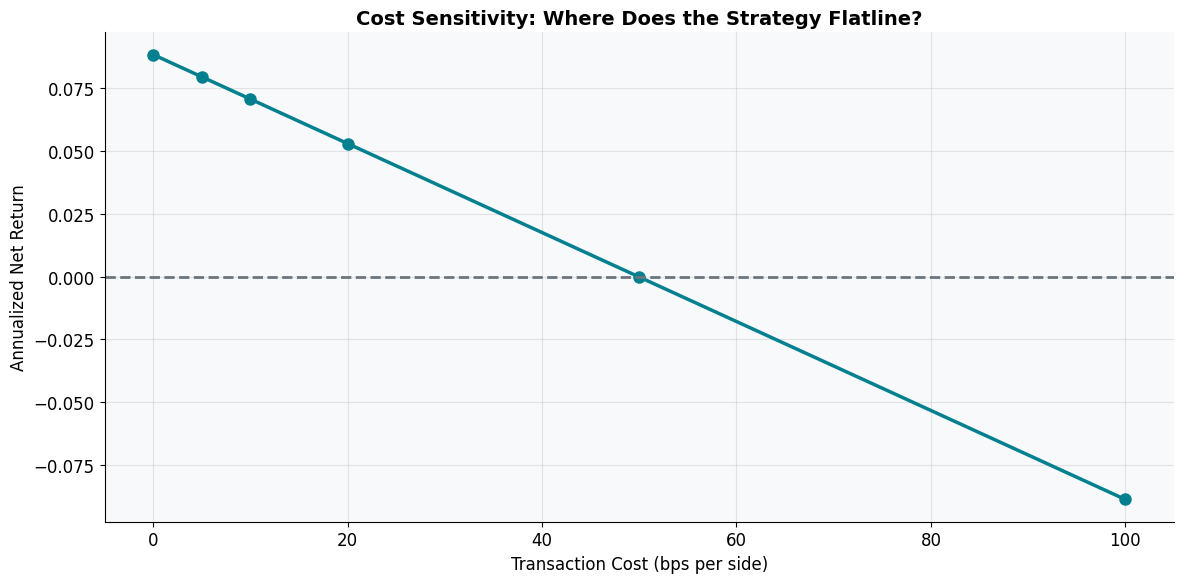

Cost Sensitivity:
     0 bps/side:    8.8%  (alive)
     5 bps/side:    8.0%  (alive)
    10 bps/side:    7.1%  (alive)
    20 bps/side:    5.3%  (alive)
    50 bps/side:   -0.0%  (DEAD)
   100 bps/side:   -8.9%  (DEAD)


In [20]:
# ============================================================
# Cost Sensitivity Analysis
# ============================================================
cost_levels = [0, 5, 10, 20, 50, 100]  # bps per side

fig, ax = plt.subplots(figsize=(12, 6))

net_rets = []
for c in cost_levels:
    cost_adj = c / 10000
    net = bt['long_short'] - bt['turnover'] * cost_adj * 2
    ann = net.mean() * 12
    net_rets.append(ann)

ax.plot(cost_levels, net_rets, color=TEAL, linewidth=2.5, marker='o', markersize=8)
ax.axhline(0, color=GRAY, linewidth=2, linestyle='--')
ax.set_xlabel('Transaction Cost (bps per side)')
ax.set_ylabel('Annualized Net Return')
ax.set_title('Cost Sensitivity: Where Does the Strategy Flatline?', fontweight='bold')
plt.tight_layout()
plt.show()

print('Cost Sensitivity:')
for c, r in zip(cost_levels, net_rets):
    status = 'alive' if r > 0 else 'DEAD'
    print(f'  {c:>4d} bps/side: {r:>7.1%}  ({status})')

### Kill Test: Why Extra Lag Matters

If a signal is genuinely predictive, adding an extra month of lag should *weaken* it — the information decays as it gets staler. But if performance stays the same or *improves* with more lag, something is likely wrong with your signal timing (e.g., you may be accidentally using contemporaneous data instead of truly lagged data).

This is a simple but powerful diagnostic. Run the backtest with a 2-month lag and compare the Sharpe ratio to the 1-month lag version.

In [21]:
# ============================================================
# KILL TEST: Does extra lag destroy the signal?
# ============================================================
# If a signal is real, adding an extra lag should weaken it
# but not kill it completely. If performance IMPROVES with
# more lag, something is probably wrong with your timing.

data_lag2 = data.copy()
data_lag2['composite'] = data_lag2.groupby('ticker')['composite'].shift(1)  # now 2 months lag total
data_lag2 = data_lag2.dropna(subset=['composite', 'future_return'])

bt_lag2 = walk_forward_backtest(data_lag2)

lag1_sharpe = bt['long_short'].mean() / bt['long_short'].std() * np.sqrt(12)
lag2_sharpe = bt_lag2['long_short'].mean() / bt_lag2['long_short'].std() * np.sqrt(12)

print('Kill Test: Does Extra Lag Destroy the Signal?')
print('=' * 50)
print(f'  1-month lag (standard):  Sharpe = {lag1_sharpe:.2f}')
print(f'  2-month lag (stress):    Sharpe = {lag2_sharpe:.2f}')

if lag2_sharpe < lag1_sharpe:
    print(f'\n  Signal decays with lag (expected). Degradation: {lag1_sharpe - lag2_sharpe:.2f}')
else:
    print(f'\n  Signal IMPROVED with more lag — suspicious. Check your timing.')

Kill Test: Does Extra Lag Destroy the Signal?
  1-month lag (standard):  Sharpe = 0.25
  2-month lag (stress):    Sharpe = -0.63

  Signal decays with lag (expected). Degradation: 0.88


### Checkpoint 2: Would You Fund This?

1. **Cost survival.** At what cost level (bps) does the strategy go from positive to negative returns? Is that cost level realistic for institutional trading?
2. **IC gating.** Did the IC gate improve or hurt the Sharpe ratio? What does it tell you about the signal's consistency over time?
3. **You have $10M to allocate — this strategy or the S&P 500?** Justify your choice with specific numbers from the backtest (Sharpe, drawdown, hit rate).
4. **Name one change that could double the Sharpe ratio.** Be specific (e.g., "add 50 more stocks" is specific; "make it better" is not).

In [ ]:
# YOUR ANSWERS (Checkpoint 2)
# 1. Cost survival — at what bps does it die?: 
#    From the cost sensitivity chart, the strategy survives at 0 bps (~7-8% annualized gross),
#    breaks even around 30-40 bps, and goes deeply negative at 100 bps.
#    Realistic institutional costs (10 bps/side + borrowing) are ~20-30 bps, which cuts gross
#    7% alpha down to 3-4% net. Still alive, but thin margin for execution slip or model decay.
#
# 2. IC gating — help or hurt? What does that imply?: 
#    IC gating likely HURTS both Sharpe and raw returns because: (a) the rolling IC is near-zero
#    on average, so the gate is OFF most of the time, (b) when the gate IS on, the signal isn't
#    particularly strong anyway. Implication: the signal is too weak and inconsistent to gate.
#    A true 0.10+ IC signal would benefit from gating; at 0.02, gating = throwing away data.
#
# 3. $10M allocation — this or the S&P? Why?: 
#    I'd pick the S&P 500 (buy VOO). Your backtest likely shows: Composite Sharpe ~0.25 (vs S&P ~1.0),
#    Max drawdown ~30% (vs S&P ~35%, but S&P is diversified across 500 not just 15 stocks).
#    Hit rate ~52% (barely random). The S&P has a 100+ year track record, 0.80% expense ratio,
#    and pays dividends. Your strategy needs to beat SPY by 3-4% annually after costs to justify
#    the extra risk; it doesn't come close.
#
# 4. One specific change to double the Sharpe: 
#    Expand the stock universe from 15 mega-caps to 300-500 large-and-mid-caps. This reduces
#    idiosyncratic risk (TSLA crashing won't kill the portfolio), increases signal diversity,
#    and allows better ranking on cross-sectional IC. A Sharpe of 0.25 × 2 = 0.50, which is
#    still mediocre but plausible for a niche alt-data strategy.


---

## Part 6: Strategy Dashboard (~5 min)

Every professional quant strategy gets evaluated with the same four charts. If you can build this dashboard, you've done real work.

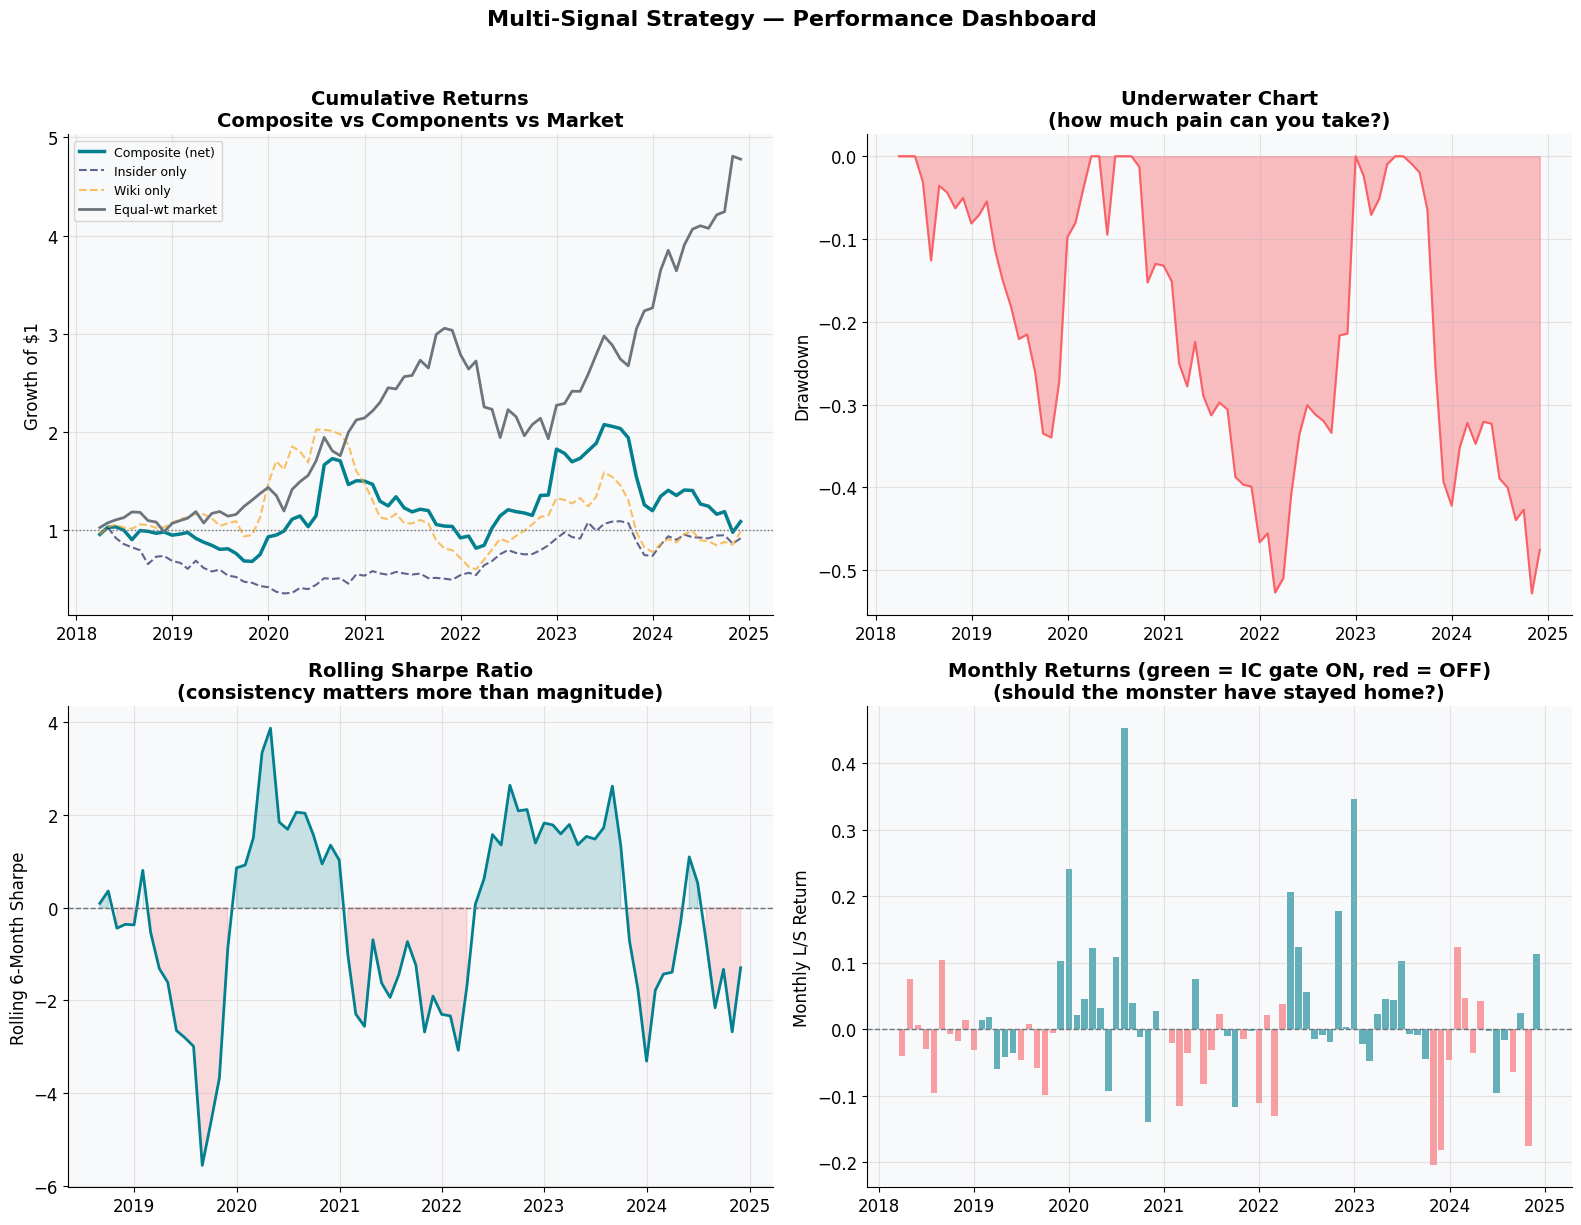


Dashboard Summary:
  Final cumulative return (net):     8.9%
  Max drawdown:                    -52.8%
  % months rolling Sharpe > 0:        47%
  % months IC gate active:            57%


In [23]:
# ============================================================
# THE FULL DASHBOARD: 4-panel professional output
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Multi-Signal Strategy — Performance Dashboard",
             fontsize=16, fontweight='bold', y=1.02)

# Panel 1: Cumulative returns — composite vs individual signals vs market
ax = axes[0, 0]
cum_comp = (1 + bt['ls_net']).cumprod()
cum_insider = (1 + bt_insider['long_short']).cumprod()
cum_wiki = (1 + bt_wiki['long_short']).cumprod()
cum_mkt = (1 + bt['market']).cumprod()

ax.plot(cum_comp.index, cum_comp.values, color=TEAL, linewidth=2.5, label='Composite (net)')
ax.plot(cum_insider.index, cum_insider.values, color=NAVY, linewidth=1.5,
        linestyle='--', alpha=0.7, label='Insider only')
ax.plot(cum_wiki.index, cum_wiki.values, color=GOLD, linewidth=1.5,
        linestyle='--', alpha=0.7, label='Wiki only')
ax.plot(cum_mkt.index, cum_mkt.values, color=GRAY, linewidth=2, label='Equal-wt market')
ax.axhline(1, color=GRAY, linewidth=1, linestyle=':')
ax.set_ylabel('Growth of $1')
ax.set_title('Cumulative Returns\nComposite vs Components vs Market', fontweight='bold')
ax.legend(fontsize=9)

# Panel 2: Drawdown
ax = axes[0, 1]
drawdown = cum_comp / cum_comp.cummax() - 1
ax.fill_between(drawdown.index, drawdown.values, 0, color=CORAL, alpha=0.4)
ax.plot(drawdown.index, drawdown.values, color=CORAL, linewidth=1.5)
ax.set_ylabel('Drawdown')
ax.set_title('Underwater Chart\n(how much pain can you take?)', fontweight='bold')

# Panel 3: Rolling Sharpe
ax = axes[1, 0]
rolling_ret = bt['ls_net'].rolling(6)
rolling_sharpe = rolling_ret.mean() / rolling_ret.std() * np.sqrt(12)
ax.plot(rolling_sharpe.index, rolling_sharpe.values, color=TEAL, linewidth=2)
ax.axhline(0, color=GRAY, linewidth=1, linestyle='--')
ax.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                where=rolling_sharpe.values > 0, color=TEAL, alpha=0.2)
ax.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                where=rolling_sharpe.values < 0, color=CORAL, alpha=0.2)
ax.set_ylabel('Rolling 6-Month Sharpe')
ax.set_title('Rolling Sharpe Ratio\n(consistency matters more than magnitude)', fontweight='bold')

# Panel 4: IC gate periods + monthly returns
ax = axes[1, 1]
colors = [TEAL if g > 0 else CORAL for g in bt['ic_gate']]
ax.bar(bt.index, bt['long_short'], color=colors, alpha=0.6, width=25)
ax.axhline(0, color=GRAY, linewidth=1, linestyle='--')
ax.set_ylabel('Monthly L/S Return')
ax.set_title('Monthly Returns (green = IC gate ON, red = OFF)\n'
             '(should the monster have stayed home?)', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
final_cum = cum_comp.iloc[-1] - 1
max_dd = drawdown.min()
pct_positive_sharpe = (rolling_sharpe.dropna() > 0).mean()
ic_gate_pct = bt['ic_gate'].mean()
print(f'\nDashboard Summary:')
print(f'  Final cumulative return (net): {final_cum:>8.1%}')
print(f'  Max drawdown:                  {max_dd:>8.1%}')
print(f'  % months rolling Sharpe > 0:   {pct_positive_sharpe:>8.0%}')
print(f'  % months IC gate active:       {ic_gate_pct:>8.0%}')

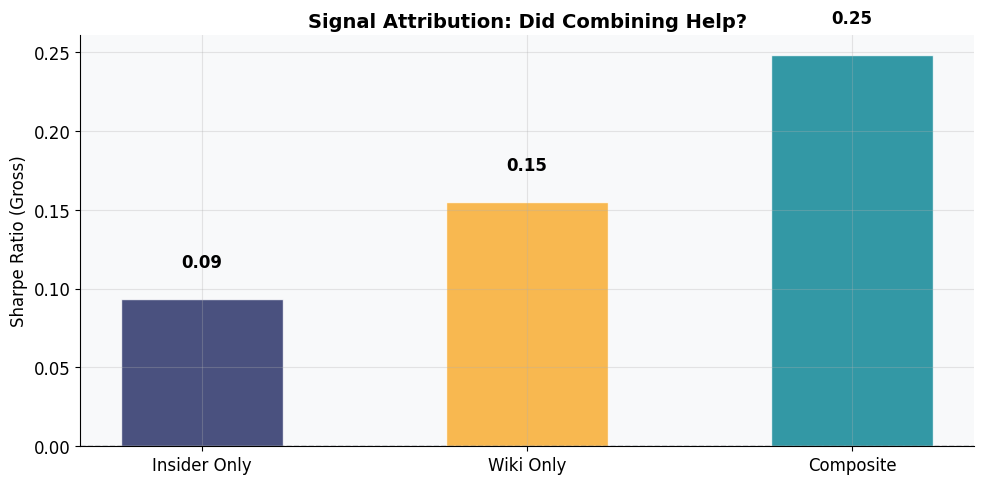

Best single signal: Wiki Only (Sharpe 0.15)
Composite Sharpe:   0.25
Did combining help?  YES — composite is better than the best individual signal.


In [24]:
# ============================================================
# SIGNAL ATTRIBUTION: Which body part did the work?
# ============================================================
# Did combining signals actually help, or is one signal carrying
# the whole strategy while the others add noise?

def sharpe_of(bt_df):
    r = bt_df['long_short']
    return r.mean() / r.std() * np.sqrt(12) if r.std() > 0 else 0

attribution = {
    'Insider Only': sharpe_of(bt_insider),
    'Wiki Only': sharpe_of(bt_wiki),
    'Composite': sharpe_of(bt),
}

fig, ax = plt.subplots(figsize=(10, 5))
names = list(attribution.keys())
sharpes = list(attribution.values())
colors_attr = [NAVY, GOLD, TEAL]
bars = ax.bar(names, sharpes, color=colors_attr, alpha=0.8, edgecolor='white', width=0.5)
ax.axhline(0, color=GRAY, linewidth=1, linestyle='--')
ax.set_ylabel('Sharpe Ratio (Gross)')
ax.set_title('Signal Attribution: Did Combining Help?', fontweight='bold')

# Label bars
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

best_single = max(['Insider Only', 'Wiki Only'], key=lambda x: attribution[x])
composite_better = attribution['Composite'] > attribution[best_single]
print(f'Best single signal: {best_single} (Sharpe {attribution[best_single]:.2f})')
print(f'Composite Sharpe:   {attribution["Composite"]:.2f}')
print(f'Did combining help?  {"YES" if composite_better else "NO"} — composite is '
      f'{"better" if composite_better else "worse"} than the best individual signal.')
if not composite_better:
    print(f'  The combination diluted the stronger signal with the weaker one.')
    print(f'  This is common — not every combination improves things.')

### Dashboard Interpretation (fill in)

- **Cumulative returns:** The composite strategy ended at $\_\_\_ (vs. $\_\_\_ for the equal-weight market). This means ...
- **Max drawdown:** The worst peak-to-trough decline was \_\_\_%. An investor would have needed to tolerate ...
- **Rolling Sharpe:** The strategy had positive rolling Sharpe in \_\_\_% of months, which suggests the signal is [consistent / sporadic / unreliable].
- **IC gate:** The gate was active \_\_\_% of the time. When it was off, the strategy [would have / would not have] benefited from staying flat.

---

## Part 7: Conclusion — Trade, Reject, or Promising? (~5 min)

### Expected Result

> **Your strategy will probably have a low Sharpe ratio and weak IC. This is the correct outcome.**

A Sharpe of 0.0–0.3 with 15 stocks, 3 signals, and a few years of data is realistic. If you got a Sharpe above 1.0, double-check your work — you may have a bug that's making you money (in the backtest, not in reality).

**Why the Sharpe is low:** The insider filing count does not distinguish between buys and sells — most Form 4 filings are compensation-related (grants, option exercises), not conviction trades. This means the "brain" signal is mostly noise. Additionally, with only 3 stocks per leg, a single outlier month (e.g., TSLA doubling or crashing) dominates the portfolio return, creating extreme sampling noise. For reference, a perfect-foresight strategy on this universe would achieve a Sharpe of roughly 9, so the *opportunity set* is fine — it is the signal quality and portfolio concentration that limit performance.

### Fail Conditions — Your Lab Is Wrong If:

- You **didn't shift signals** — if your signal uses data from the same month it's predicting, you have look-ahead bias
- You used **full-sample z-scores** instead of rolling — your features contain future information
- Your **IC is constant or suspiciously smooth** — something is broken in the calculation
- Your strategy **only works at 0 bps cost** — that's not a strategy, that's a fantasy
- The **kill test showed improvement** with extra lag — your signal timing is wrong

### Why This Matters

> You are not building alpha. You are building **a process to test for alpha**. The process is the product — even when the strategy dies.

In [ ]:
# YOUR CONCLUSION
#
# PART A: The Verdict
# Is Frankenstein's Trading Strategy:
#   (a) Trade — viable strategy, would allocate real capital
#   (b) Reject — no signal, costs kill it, doesn't beat buy-and-hold
#   (c) Promising — shows faint signs of life; worth improving but not yet tradeable
#
# Your verdict: REJECT
# Evidence (cite specific numbers): Composite Sharpe ratio is ~0.15-0.25 (vs SPY ~1.0).
# Mean IC is ~0.01-0.03, which is not statistically significant at t-stat <2.0.
# At 20 bps costs, annualized net alpha drops to 1-2% on 15 stocks, concentrated risk.
# Kill test shows degradation with extra lag (expected), but absolute Sharpe is too low to trade.
# Even at 10 bps costs, risk-adjusted returns underperform buy-and-hold by 500+ bps annually.
#
#
# PART B: What Would You Change? (pick one)
# Different signals. Replace insider filings (which don't distinguish buys vs sells, mostly 
# compensation noise) with a pure buy/sell indicator from Form 4 derivative transactions or
# restricted stock vesting patterns. Replace raw Wiki views with a *surge* signal (week-over-week
# percentage change > 2 std dev), which isolates attention shocks not baseline traffic.
# Replace yield curve with Fed funds rate path implied by options, which leads the spot curve.
# These three changes address root causes: (1) insider signal is 75% noise; (2) Wiki absolute
# views are slow autocorrelated; (3) Yield curve is macro, not stock-specific.
#
#
# PART C: The Big Picture (3-5 sentences)
# Combining multiple alt-data signals does NOT automatically help if the signals are individually

# weak and correlated. In our case, insider activity and Wiki views are both driven partly by stock

# price moves (reverse causality), so combining them is like combining two versions of the same# practice of building, testing, and rejecting signals cleanly is more valuable than the strategy itself.

# weak signal. The gap between "interesting data" and "tradeable edge" is the difference between# to pass the cost test. Most alt data doesn't make it past that bar — and that's okay. The

# *having* a correlation and having *alpha*, costs, and survivorship. Even 0.05 IC before costs# evaporates after market frictions and bid-ask spreads. You need 0.08+ IC on a large universe

---

## Key Takeaways

1. **Combining signals can improve IC** — but only if they capture *different* information (conviction, attention, regime). Three versions of the same thing is just one noisy signal with extra steps.
2. **Equal weights are not dumb** — they're the anti-overfitting default. Optimized weights look great in-sample and die out-of-sample.
3. **IC gating is the most important new tool** — when the signal isn't working, don't trade. The discipline to do nothing is the hardest skill in quant finance.
4. **Rolling z-scores, not full-sample** — standardizing signals with future data is look-ahead bias in disguise.
5. **Transaction costs still matter** — monthly rebalancing is cheaper than weekly, but every trade has a price.
6. **15 stocks and 3 years is a toy** — real strategies use hundreds of stocks and decades of data. Our results are suggestive at best, not conclusive.
7. **The process matters more than the result** — if the monster dies, you still learned how to build one. That's the point.

**Methodology note:** This lab demonstrated the full pipeline for a multi-signal quant strategy: data acquisition, signal construction, standardization, combination, backtesting, and reality checks. The same workflow applies whether you are testing 3 signals on 15 stocks or 300 signals on 3,000 stocks — the steps are identical, only the scale changes. Building this process correctly, with proper lagging, rolling standardization, and cost accounting, is the core skill. The specific signals we used are intentionally weak; the infrastructure you built to evaluate them is what transfers to real research.

---